In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread, imsave
from time import time, gmtime, strftime

In [16]:
# 1. Cargar imagen y escalar
img = imread(r"Datos/kodim21.png") 
if img.max() <= 1.0:
    img = (img * 255).astype(np.uint8)
pixels = img.reshape(-1, 3)  # Cada píxel es un vector RGB

In [17]:
# 2. Modelo GMM
class GMM():
    def __init__(self, K, tol=1e-6, max_iters=1000):
        self.K = K
        self.tol = tol
        self.max_iters = max_iters
        self.init_params =  {}
        self.pi = None
        self.mu = None
        self.Sigma = None
        self.log_verosimilitud = []

    # _ hace que el método no pueda ser llamado directamente
    # método privado
    def _inicializacion(self, X):
        n, d = X.shape
        self.pi = np.full(self.K, 1 / self.K)
        # Elijo los centroides de las clases a partir
        # de unos ejemplos del dataset
        indices = np.random.choice(n, self.K, replace=False)
        self.mu = X[indices]
        # Los sigmas los inicializo como la matriz de covarianza
        # de todo el dataset
        self.Sigma = np.array([np.cov(X, rowvar=False) for clase in range(self.K)])

    def _paso_e(self, X):
        n, d = X.shape
        # Hago los w^i_j
        w = np.zeros((n, self.K))
        # Para cada clase
        for k in range(self.K):
            diff = X - self.mu[k]
            # Regularización para evitar matrices singulares
            if np.linalg.det(self.Sigma[k]) < 1e-6:
                self.Sigma[k] += np.eye(self.Sigma[k].shape[0]) * 1e-6 # suma una pequeña cantidad a la diagonal para que sea invertible
            inv_cov = np.linalg.inv(self.Sigma[k])
            exp = np.exp(-0.5 * np.sum(np.dot(diff, inv_cov) * diff, axis=1))
            denom = np.sqrt(((2 * np.pi) ** d) * np.linalg.det(self.Sigma[k]))
            # Calculo la probabilidad de que los datos pertenezcan a ella
            w[:, k] = self.pi[k] * exp / denom
        # Normalizo los pesos para que sumen 1    
        w_sum = w.sum(axis=1, keepdims=True)
        w /= w_sum
        return w, w_sum

    def _paso_m(self, X, w):
        n, d = X.shape
        # La suma de w_k para todos los datos
        Nk = w.sum(axis=0)
        self.pi = Nk / n
        self.mu = (np.dot(w.T, X)) / Nk[:, None]
        for k in range(self.K):
            diff = X - self.mu[k]
            self.Sigma[k] = np.dot((w[:, k][:, None] * diff).T , diff) / Nk[k]

    def fit(self, X):

        X = np.asarray(X)
        self._inicializacion(X)
        self.log_verosimilitud = []

        for iteracion in range(self.max_iters):
            w,w_sum = self._paso_e(X)
            lver = np.sum(np.log(w_sum))
            self.log_verosimilitud.append(lver)
            if iteracion > 0 and abs(self.log_verosimilitud[-1] - self.log_verosimilitud[-2]) < self.tol:
                break
            self._paso_m(X, w)
        return self

    def predict_proba(self, X):
        # Probabilidad de cada clase
        X = np.asarray(X)
        w,_ = self._paso_e(X)
        return w

    def predict(self, X):
        # Asignar un label
        w = self.predict_proba(X)
        return np.argmax(w, axis=1)

In [18]:
# 3. Función para comprimir imagen con muestreo y corrección de escala
def comprimir_con_GMM(imagen_rgb, cantidad_colores):
    """se intentó usar un tamaño de muestra fijo, pero no funcionó bien con K grandes, tuvimos que adaptarlo por problemas de memoria"""
    #muestra = min(int(20  * cantidad_colores), len(imagen_rgb)) # usamos un tamaño de muestra proporcional a la cantidad de colores
    #print(f"Usando {muestra} píxeles de muestra para {cantidad_colores} colores")
    #np.random.seed(42)
    #indices = np.random.choice(imagen_rgb.shape[0], size=muestra, replace=False)
    #muestra_pixeles = imagen_rgb[indices]

    modelo = GMM(K=cantidad_colores, max_iters=30, tol=1e-4)
    modelo.fit(imagen_rgb)
    pred = modelo.predict(imagen_rgb)

    colores_representativos = modelo.mu
    if colores_representativos.max() <= 1.0:
        colores_representativos *= 255 

    imagen_comprimida = colores_representativos[pred].reshape(img.shape)
    imagen_comprimida = np.clip(imagen_comprimida, 0, 255).astype(np.uint8)
    return imagen_comprimida



Comenzando compresión con 100 colores...
Duración: 00:04:01


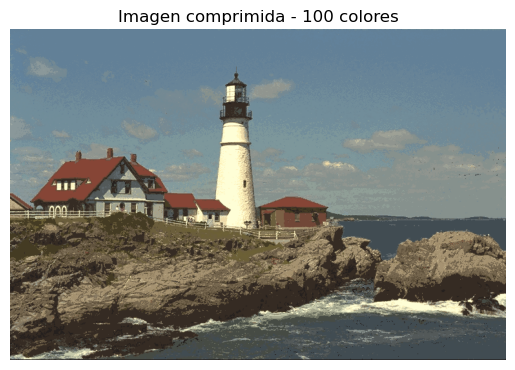


Comenzando compresión con 200 colores...
Duración: 00:08:13


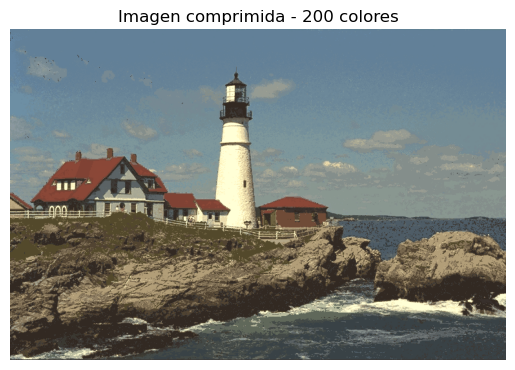


Comenzando compresión con 500 colores...
Duración: 00:23:26


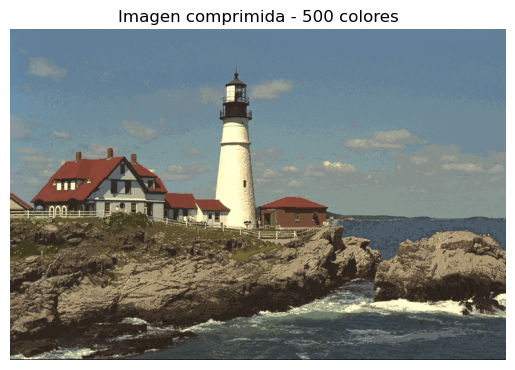


Comenzando compresión con 1000 colores...
Duración: 00:47:29


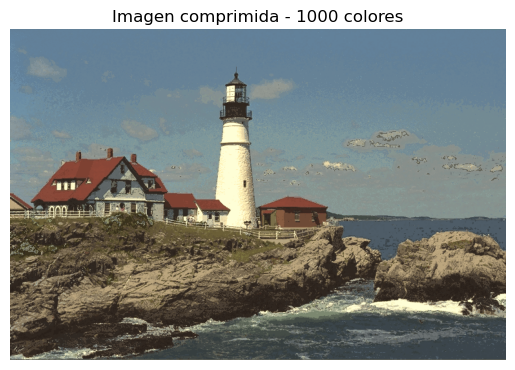


Comenzando compresión con 10000 colores...


MemoryError: Unable to allocate 29.3 GiB for an array with shape (393216, 10000) and data type float64

In [19]:
# 4. Ejecutar para diferentes valores de K
valores_K = [100, 200, 500, 1000, 10000]
imagenes_resultado = {}
tiempos = []

for K in valores_K:
    print(f"\nComenzando compresión con {K} colores...")
    
    inicio = time()
    comprimida = comprimir_con_GMM(pixels, K)  # ← podés ajustar la muestra si querés
    duracion = time() - inicio
    
    tiempos.append(duracion)

    print(f"Duración: {strftime('%H:%M:%S', gmtime(duracion))}")
    imsave(f"kodim21_comprimida_{K}.png", comprimida)
    imagenes_resultado[K] = comprimida

    plt.imshow(comprimida)
    plt.title(f"Imagen comprimida - {K} colores")
    plt.axis("off")
    plt.show()

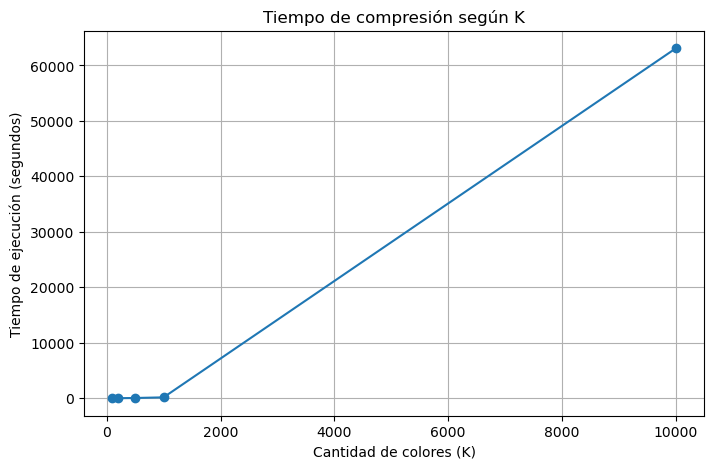

In [ ]:
# 5. Gráfico de tiempo vs K
plt.figure(figsize=(8, 5))
plt.plot(valores_K, tiempos, marker='o')
plt.xlabel("Cantidad de colores (K)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Tiempo de compresión según K")
plt.grid(True)
plt.show()

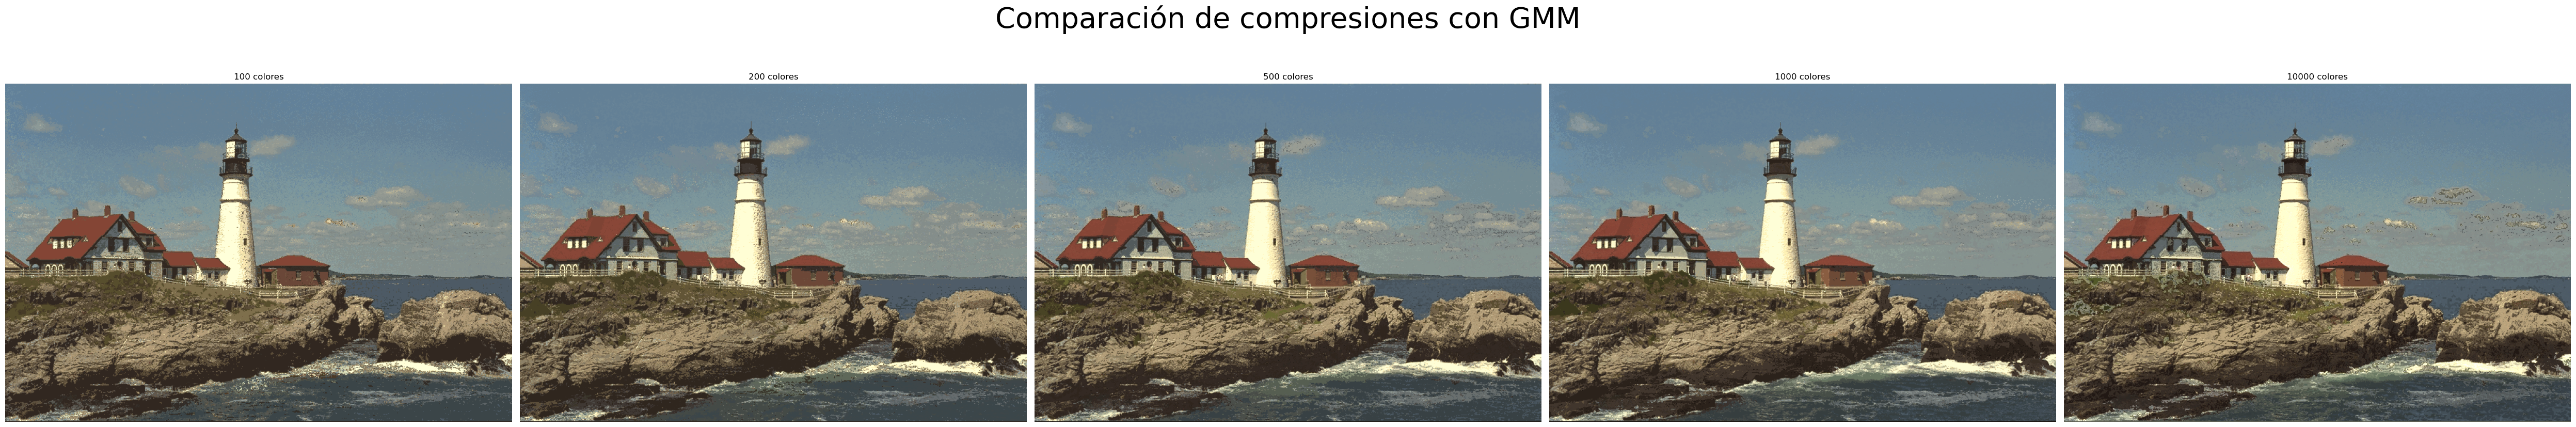

In [ ]:
# 6. Grilla comparativa de imágenes
fig, axs = plt.subplots(1, len(valores_K), figsize=(50, 10))
for i, K in enumerate(valores_K):
    axs[i].imshow(imagenes_resultado[K])
    axs[i].set_title(f"{K} colores")
    axs[i].axis("off")
plt.tight_layout()
plt.suptitle("Comparación de compresiones con GMM", fontsize=40)
plt.show()

En comparación y como se puede ver de 100 a 10000 colores la imagen va mejorando, en la parte de 10000 tuvimos problemas con el muestreo, probamos distintos ajustes pero o tardaba mucho o la calidad no era buena. Terminó siendo que la calidad en 10000 colores no es tan bueno sino que es peor que la de 1000 colores, lo que nos hace pensar que quizas o estamos cometiendo algún error en el muestrueo o la implementación o que la realidad es que GMM no es bueno para cuando tenes 10000 colores posibles, la reconstrución produce una imagen de menor calidad.